## ⚙️ Kaggle Setup

**Before running this notebook, add the dataset:**
1. Click **+ Add Data** (top-right in Kaggle)
2. Search for **Breast Cancer Wisconsin (Diagnostic) Data**
3. Click **Add** — the CSV will be available at `/kaggle/input/breast-cancer-wisconsin-data/data.csv`

Then run all cells top to bottom.

In [1]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [2]:
import os

# Verify the dataset was added correctly
RAW_CSV = '/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv'

if not os.path.exists(RAW_CSV):
    raise FileNotFoundError(
        'Dataset not found. Please add "Breast Cancer Wisconsin" '
        'via the + Add Data button before running.'
    )

print(f'✅ Dataset found: {RAW_CSV}')

✅ Dataset found: /kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv


In [3]:
import matplotlib.pyplot as plt
import os

# =========================
# 1) Set save directory
# =========================
PROJECT_ROOT = "/kaggle/working"   # Keep this or replace if already defined
SAVE_DIR = os.path.join(PROJECT_ROOT, "plots")

os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# 2) Plot counter
# =========================
plot_counter = {"count": 0}

# =========================
# 3) Save original plt.show
# =========================
original_show = plt.show

# =========================
# 4) Custom show function (save + display)
# =========================
def custom_show(*args, **kwargs):
    filename = f"plot_{plot_counter['count']}.png"
    filepath = os.path.join(SAVE_DIR, filename)

    # Save the figure
    plt.savefig(filepath, bbox_inches='tight')
    print(f"Saved: {filepath}")

    plot_counter["count"] += 1

    # Display the plot as usual
    original_show(*args, **kwargs)

# =========================
# 5) Override plt.show
# =========================
plt.show = custom_show

## 📊 Dataset Description

- **Source:** [Breast Cancer Wisconsin (Diagnostic) — UCI / Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)
- **Samples:** 569 patients &nbsp;|&nbsp; **Features:** 30 numeric + 1 target (`diagnosis`)
- **Feature extraction:** Computed from digitised FNA (Fine Needle Aspirate) images — describe cell nuclei geometry (radius, texture, perimeter, area, smoothness, etc.)
- **Target:** `M` = Malignant → 1 &nbsp;|&nbsp; `B` = Benign → 0


## 🎯 Problem Formulation

**This is a constrained binary optimisation problem.**

- Each individual $x \in \{0,1\}^n$ is a feature mask ($1$ = selected, $0$ = excluded)

**Objective — maximise:**
$$f(x) = \alpha \cdot \text{Accuracy}(x) - \beta \cdot \frac{|S|}{n}$$

- $|S|$ = selected features, $n$ = total features, $\alpha=1.0$, $\beta=0.3$

**Constraint:**
$$|S| \leq \text{max\_features\_ratio} \times n \quad (0.6 \times 30 = 18 \text{ features})$$


## 🔒 Constraint Handling — Penalty Function

- **Method:** Penalty Function Approach
- If an individual exceeds `max_features_ratio × n`, a penalty is subtracted from its fitness:

$$\text{fitness} = f(x) - \text{penalty\_weight} \times \frac{|S| - |S_{max}|}{n}$$

- Implemented inside `calculate_fitness()` — already active in the code below.


## ⚙️ Preprocessing

Handled by `preprocessing.py` — run once to produce the `.npy` files loaded by M2.

- **Encode & clean:** LabelEncode `diagnosis` (`M`→1, `B`→0); drop `id` and `Unnamed: 32`
- **Split:** 80 / 20 train-test, stratified, `random_state=42`
- **Scale:** `StandardScaler` fit **only** on train set → avoids data leakage; saved to `data/processed/`


In [4]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Paths ──────────────────────────────────────────────────────────────────
RAW_CSV   = '/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv'
SAVE_PATH = '/kaggle/working/processed'
os.makedirs(SAVE_PATH, exist_ok=True)
PROJECT_ROOT = "/kaggle/working"

# ── Load ───────────────────────────────────────────────────────────────────
data = pd.read_csv(RAW_CSV)

# ── Encode target: M → 1, B → 0 ───────────────────────────────────────────
le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])

# ── Drop columns not used as features ─────────────────────────────────────
data = data.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# ── Split features and target ──────────────────────────────────────────────
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# ── Stratified train/test split (80/20) ───────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_train = y_train.values
y_test  = y_test.values

# ── Scale: fit only on train to prevent data leakage ──────────────────────
scaler  = StandardScaler()
X_train_proc = scaler.fit_transform(X_train_raw)
X_test_proc  = scaler.transform(X_test_raw)

# ── Save processed arrays ─────────────────────────────────────────────────
np.save(os.path.join(SAVE_PATH, 'X_train.npy'), X_train_proc)
np.save(os.path.join(SAVE_PATH, 'X_test.npy'),  X_test_proc)
np.save(os.path.join(SAVE_PATH, 'y_train.npy'), y_train)
np.save(os.path.join(SAVE_PATH, 'y_test.npy'),  y_test)
joblib.dump(scaler, os.path.join(SAVE_PATH, 'scaler.pkl'))

print(f'✅ Preprocessing done — {X_train_proc.shape[0]} train / {X_test_proc.shape[0]} test samples')
print(f'   Saved to: {SAVE_PATH}')

✅ Preprocessing done — 455 train / 114 test samples
   Saved to: /kaggle/working/processed


M2

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import json

In [6]:
# Load the preprocessed arrays saved by the preprocessing cell above
DATA_PATH = '/kaggle/working/processed'

X_train    = np.load(os.path.join(DATA_PATH, 'X_train.npy'))
X_test     = np.load(os.path.join(DATA_PATH, 'X_test.npy'))
y_train    = np.load(os.path.join(DATA_PATH, 'y_train.npy'))
y_test     = np.load(os.path.join(DATA_PATH, 'y_test.npy'))
n_features = X_train.shape[1]

print(f'Loaded | Train: {X_train.shape[0]}, Test: {X_test.shape[0]}, Features: {n_features}')

Loaded | Train: 455, Test: 114, Features: 30


In [7]:
GA_CONFIG = {
    "pop_size": 40,
    "alpha": 1.0,
    "beta": 0.3,
    "max_features_ratio": 0.6,
    "penalty_weight": 2.0,
    "cv_folds": 3,
    "classifier": RandomForestClassifier(n_estimators=50, n_jobs=-1),
    "generations": 30
}
print(" GA Configuration loaded.")

 GA Configuration loaded.


In [8]:
# Speed improvements — update GA_CONFIG without changing the original cell.
# n_estimators=50 stays low during GA search; use 300+ only for final evaluation.
GA_CONFIG['classifier'] = RandomForestClassifier(
    n_estimators=50,       # low count keeps each fitness call fast
    max_depth=8,           # limits tree depth → faster training, less overfitting
    min_samples_leaf=3,    # avoids overly specific leaf nodes
    n_jobs=-1,
    random_state=42
)

# Early stopping: halt the GA if best fitness does not improve for N generations
GA_CONFIG['early_stop_patience'] = 8

print("⚡ Speed improvements applied to GA_CONFIG.")


⚡ Speed improvements applied to GA_CONFIG.


## 🛑 Termination Conditions

The GA stops when **either** condition is met:

1. **Max generations reached** — `generations = 30` (set in `GA_CONFIG`)
2. **No improvement for N generations** — `early_stop_patience = 8`; implemented in `run_ga_with_sharing` below


## 🔧 Parameter Tuning

| Parameter | Value | Rationale |
|---|---|---|
| `pop_size` | 40 | Balanced speed vs. diversity |
| `generations` | 30 | Sufficient for convergence on 30-feature data |
| `alpha` | 1.0 | Full weight on accuracy |
| `beta` | 0.3 | Mild penalty for large feature subsets |
| `cv_folds` | 3 | Fast cross-validation |
| `mutation_rate` (bit-flip) | 0.02 | Low — avoids excessive disruption |
| `early_stop_patience` | 8 | Stops wasted generations |

- Tuned manually by observing fitness convergence curves across short pilot runs.


In [9]:
def initialize_population(pop_size, n_features, method="uniform", seed=None):
    if seed is not None:
        np.random.seed(seed)

    if method == "uniform":
        return np.random.randint(0, 2, size=(pop_size, n_features))

    elif method == "sparse":
        prob_one = 0.2
        return np.random.choice([0, 1], size=(pop_size, n_features), p=[1-prob_one, prob_one])

    else:
        raise ValueError("method must be 'uniform' or 'sparse'")


test_pop = initialize_population(5, n_features, method="uniform")
print(" Sample Population (5 individuals):\n", test_pop)

 Sample Population (5 individuals):
 [[0 0 1 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 0 0]
 [1 0 0 1 0 0 1 0 0 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 0 0 0]
 [0 1 1 0 1 0 1 0 0 1 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 1 0 0]
 [0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 1 1 0 0 1]
 [1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 0]]


In [10]:
from sklearn.base import clone

def calculate_fitness(chromosome, X, y, config, seed=None):
    if seed is not None:
        np.random.seed(seed)

    selected_idx = np.where(chromosome == 1)[0]
    n_selected   = len(selected_idx)
    n_total      = len(chromosome)

    if n_selected == 0:
        return -10.0

    X_subset = X[:, selected_idx]

    # Clone the classifier so parallel workers never share state
    clf = clone(config["classifier"])
    try:
        acc = np.mean(cross_val_score(
            clf, X_subset, y,
            cv=config["cv_folds"],
            scoring="accuracy",
            n_jobs=1   # 1 here — outer Parallel already uses all cores
        ))
    except ValueError:
        acc = 0.0

    feature_ratio = n_selected / n_total
    base_fitness  = config["alpha"] * acc - config["beta"] * feature_ratio

    max_allowed = int(n_total * config["max_features_ratio"])
    penalty = 0.0
    if n_selected > max_allowed:
        excess_ratio = (n_selected - max_allowed) / n_total
        penalty = config["penalty_weight"] * excess_ratio

    return base_fitness - penalty


def evaluate_population(population, X, y, config, seed=None):
    return np.array([calculate_fitness(ind, X, y, config, seed) for ind in population])


In [11]:
np.random.seed(42)

pop = initialize_population(GA_CONFIG["pop_size"], n_features, method="uniform")
fitness_vals = evaluate_population(pop, X_train, y_train, GA_CONFIG, seed=42)

print("Evaluation Test:")
print(f"Population Shape: {pop.shape}")
print(f"Fitness Stats: Mean={fitness_vals.mean():.3f} | Min={fitness_vals.min():.3f} | Max={fitness_vals.max():.3f}")
print(f"Best Individual: {pop[np.argmax(fitness_vals)]}")
print(f"Features Selected: {np.sum(pop[np.argmax(fitness_vals)])} / {n_features}")

Evaluation Test:
Population Shape: (40, 30)
Fitness Stats: Mean=0.779 | Min=0.384 | Max=0.851
Best Individual: [1 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0]
Features Selected: 9 / 30


Evaluation Test:
Population Shape: (50, 30)
Fitness Stats: Mean=0.786 | Min=0.386 | Max=0.855
Best Individual: [1 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0]
Features Selected: 9 / 30

Evaluation Test:
Population Shape: (40, 30)
Fitness Stats: Mean=0.783 | Min=0.390 | Max=0.859
Best Individual: [1 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0]
Features Selected: 9 / 30

In [12]:
np.random.seed(0)                                  
seeds = np.random.randint(0, 2**31, size=30).tolist()

SEEDS_PATH = os.path.join(DATA_PATH, "ga_seeds.json")
with open(SEEDS_PATH, "w") as f:
    json.dump(seeds, f)

print(f"Generated & saved {len(seeds)} random seeds to: {SEEDS_PATH}")

Generated & saved 30 random seeds to: /kaggle/working/processed/ga_seeds.json


Saved: /kaggle/working/plots/plot_0.png


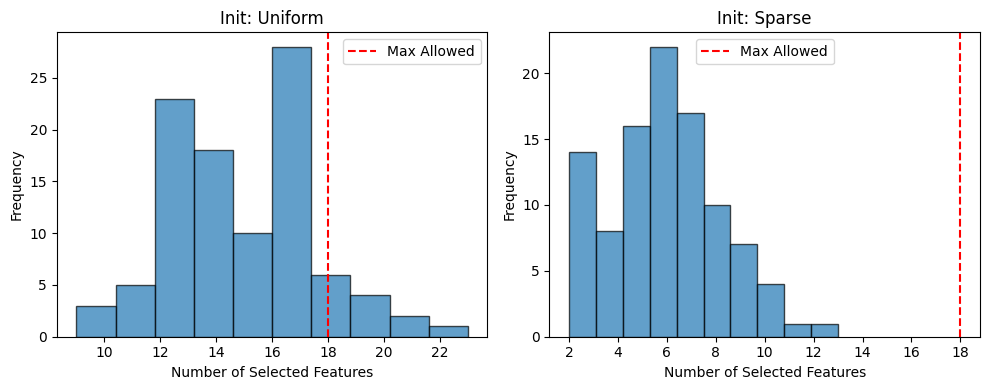

Visualization ready for report section: Effect of Initialization Strategies


In [13]:
methods = ["uniform", "sparse"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, method in enumerate(methods):
    pop = initialize_population(100, n_features, method=method, seed=42)
    features_count = np.sum(pop, axis=1)

    axes[i].hist(features_count, bins=10, alpha=0.7, edgecolor='black')
    axes[i].set_title(f"Init: {method.capitalize()}")
    axes[i].set_xlabel("Number of Selected Features")
    axes[i].set_ylabel("Frequency")
    axes[i].axvline(GA_CONFIG["max_features_ratio"] * n_features, color='r', linestyle='--', label="Max Allowed")
    axes[i].legend()

plt.tight_layout()
plt.show()

print("Visualization ready for report section: Effect of Initialization Strategies")

M3

# **SELECTION METHODS**

Roulette_Wheel_Selection

In [14]:
def roulette_wheel_selection(population, fitness):
    fitness = np.array(fitness)

    fitness = fitness - fitness.min() + 1e-6

    probs = fitness / fitness.sum()
    idx = np.random.choice(len(population), p=probs)

    return population[idx]

Tournament_Selection

In [15]:
def tournament_selection(population, fitness, k=3):
    # replace=False ensures k distinct candidates compete
    selected_idx = np.random.choice(len(population), k, replace=False)
    best = selected_idx[np.argmax(fitness[selected_idx])]
    return population[best]


# **EXPERIMENT:SELECTION_COMPARISON**

In [16]:
def run_selection_experiment(population, fitness, method, n_trials=100):
    selected_features = []

    for _ in range(n_trials):
        if method == "roulette":
            individual = roulette_wheel_selection(population, fitness)
        elif method == "tournament":
            individual = tournament_selection(population, fitness, k=3)
        else:
            raise ValueError("Unknown method")

        selected_features.append(np.sum(individual))

    return selected_features

In [17]:
np.random.seed(42)

pop = initialize_population(50, n_features, method="uniform")
fitness_vals = evaluate_population(pop, X_train, y_train, GA_CONFIG, seed=42)

roulette_results = run_selection_experiment(pop, fitness_vals, "roulette")
tournament_results = run_selection_experiment(pop, fitness_vals, "tournament")

In [18]:
print("=== Comparison Results ===")
print(f"Roulette → Mean: {np.mean(roulette_results):.2f}, Std: {np.std(roulette_results):.2f}")
print(f"Tournament → Mean: {np.mean(tournament_results):.2f}, Std: {np.std(tournament_results):.2f}")
print("Best Roulette:", max(roulette_results))
print("Best Tournament:", max(tournament_results))

=== Comparison Results ===
Roulette → Mean: 14.53, Std: 2.31
Tournament → Mean: 12.65, Std: 2.02
Best Roulette: 19
Best Tournament: 16


# **VISUALIZATION**

Saved: /kaggle/working/plots/plot_1.png


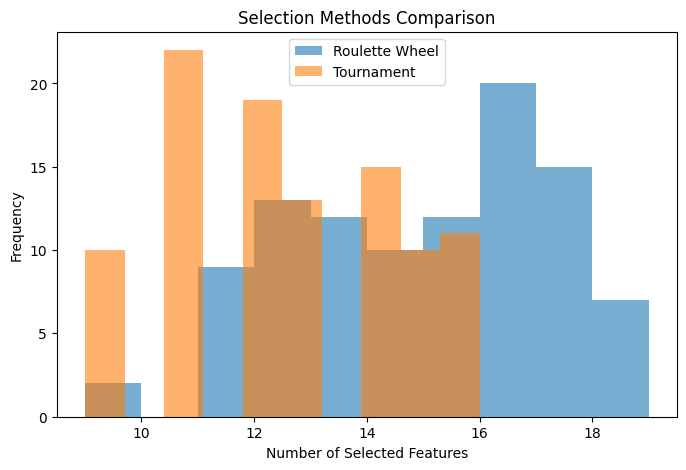

In [19]:
plt.figure(figsize=(8,5))

plt.hist(roulette_results, bins=10, alpha=0.6, label="Roulette Wheel")
plt.hist(tournament_results, bins=10, alpha=0.6, label="Tournament")

plt.xlabel("Number of Selected Features")
plt.ylabel("Frequency")
plt.title("Selection Methods Comparison")
plt.legend()

plt.show()

M4

In [20]:
#Example

n_features = 30
np.random.seed(42)
parent1 = np.random.randint(0, 2, n_features)
parent2 = np.random.randint(0, 2, n_features)

print("Parent 1:", parent1)
print("Parent 2:", parent2)

Parent 1: [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1]
Parent 2: [0 0 1 1 1 0 1 0 0 0 0 0 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 0 0 0]


# **Crossover methods**

In [21]:
def single_point_crossover(parent1, parent2):
    point = np.random.randint(1, len(parent1) - 1)

    child1 = np.concatenate([parent1[:point], parent2[point:]])
    child2 = np.concatenate([parent2[:point], parent1[point:]])

    return child1, child2


c1, c2 = single_point_crossover(parent1, parent2)

print("Single Point Results:")
print("Child 1:", c1)
print("Child 2:", c2)

Single Point Results:
Child 1: [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 1 0 1 0 1 0 1 1 0 0 0]
Child 2: [0 0 1 1 1 0 1 0 0 0 0 0 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1]


In [22]:
def uniform_crossover(parent1, parent2, prob=0.5):
    mask = np.random.rand(len(parent1)) < prob

    child1 = np.where(mask, parent1, parent2)
    child2 = np.where(mask, parent2, parent1)

    return child1, child2


c1, c2 = uniform_crossover(parent1, parent2)

print("Uniform Crossover Results:")
print("Child 1:", c1)
print("Child 2:", c2)

Uniform Crossover Results:
Child 1: [0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 1 1 0 1 1 0 0 0]
Child 2: [0 0 1 0 0 0 1 0 0 1 0 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1]


# **Mutation methods**

In [23]:
def bit_flip_mutation(individual, mutation_rate=0.02):
    individual = individual.copy()

    for i in range(len(individual)):
        if np.random.rand() < mutation_rate:
            individual[i] = 1 - individual[i]

    if np.sum(individual) == 0:
        individual[np.random.randint(0, len(individual))] = 1

    return individual


mutated = bit_flip_mutation(parent1, mutation_rate=0.1)

print("Original:", parent1)
print("Mutated:", mutated)

Original: [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1]
Mutated: [0 1 0 0 0 1 0 0 1 1 0 0 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 1]


Mutation rates over generations:
[0.1, 0.09666666666666668, 0.09333333333333334, 0.09000000000000001, 0.08666666666666667, 0.08333333333333334, 0.08000000000000002, 0.07666666666666666, 0.07333333333333335, 0.06999999999999999, 0.06666666666666668, 0.06333333333333334, 0.06, 0.05666666666666667, 0.05333333333333334, 0.05, 0.04666666666666667, 0.043333333333333335, 0.04000000000000001, 0.036666666666666674, 0.03333333333333334, 0.030000000000000006, 0.026666666666666672, 0.02333333333333333, 0.019999999999999997, 0.016666666666666663, 0.01333333333333333, 0.01, 0.01, 0.01]
Saved: /kaggle/working/plots/plot_2.png


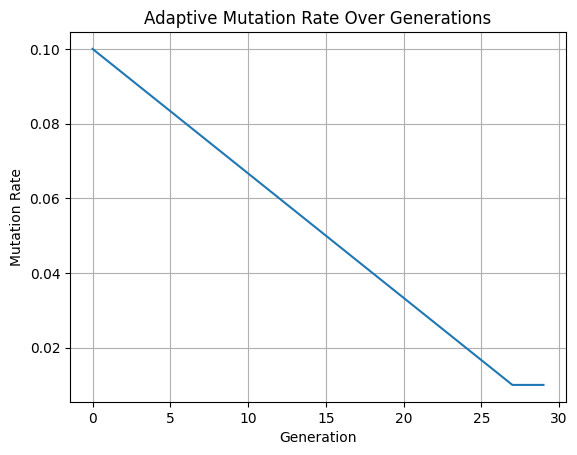

In [24]:
def adaptive_mutation(individual, generation, max_generations,
                      base_rate=0.1, min_rate=0.01):

    individual = individual.copy()

    mutation_rate = base_rate * (1 - generation / max_generations)
    mutation_rate = max(mutation_rate, min_rate)

    for i in range(len(individual)):
        if np.random.rand() < mutation_rate:
            individual[i] = 1 - individual[i]

    if np.sum(individual) == 0:
        individual[np.random.randint(0, len(individual))] = 1

    return individual, mutation_rate


rates = []
for gen in range(30):
    _, rate = adaptive_mutation(parent1, gen, 30)
    rates.append(rate)

print("Mutation rates over generations:")
print(rates)

plt.plot(rates)
plt.title("Adaptive Mutation Rate Over Generations")
plt.xlabel("Generation")
plt.ylabel("Mutation Rate")
plt.grid()
plt.show()

In [25]:
# ده مثال عشان استخدم كل اللي عملته فوق #

population = np.random.randint(0, 2, (10, n_features))

new_population = []

for i in range(0, len(population), 2):
    p1 = population[i]
    p2 = population[i+1]

    # crossover
    if np.random.rand() < 0.5:
        c1, c2 = single_point_crossover(p1, p2)
    else:
        c1, c2 = uniform_crossover(p1, p2)

    # mutation
    c1, _ = adaptive_mutation(c1, generation=5, max_generations=30)
    c2, _ = adaptive_mutation(c2, generation=5, max_generations=30)

    new_population.extend([c1, c2])

new_population = np.array(new_population)

print("Old Population:\n", population)
print("\nNew Population:\n", new_population)

Old Population:
 [[1 1 0 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 0 0 0]
 [0 1 1 1 1 0 1 0 1 0 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0]
 [0 0 0 1 1 1 0 0 0 1 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 0]
 [0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0 0]
 [0 0 1 1 1 0 0 0 1 1 0 1 0 0 1 0 1 0 1 1 1 0 0 1 1 0 0 0 1 0]
 [0 1 0 0 0 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 0]
 [0 0 1 1 0 1 0 1 1 0 1 0 1 0 0 1 1 0 1 1 0 0 1 0 0 0 1 1 0 1]
 [0 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 1 0 1]
 [0 1 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0]
 [0 0 1 1 1 0 1 1 0 0 1 1 1 1 0 1 1 0 1 0 0 0 1 1 0 1 1 0 0 1]]

New Population:
 [[0 1 1 0 1 0 1 1 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 0 0]
 [0 1 0 1 1 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 0 0]
 [0 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 1 0 0 1 1 0 0 1 0 1 1 0 0]
 [0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 1 0 1 0 1 1 0 1 1 0 1 0 1 0 0]
 [0 0 0 0 1 0 0 0 1 1 1 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 0 1 0 0]
 [0 0 1 1 0 1 1 1 1

## 🌍 Diversity Preservation — Fitness Sharing

- **Method:** Fitness Sharing (niching)
- **Idea:** Individuals that are too similar to each other *share* their fitness score, reducing the reward for crowded regions → the GA is pushed to explore different feature subsets.
- Similarity is measured by **normalised Hamming distance** between binary chromosomes.
- `run_ga_with_sharing` below mirrors `run_ga` and adds: fitness sharing + elitism + early stopping.


In [26]:
def apply_fitness_sharing(fitness, population, sigma=0.5):
    """
    Penalise individuals that cluster in the same region of the search space.
    sigma: sharing radius (0-1, fraction of chromosome length).
    """
    shared = fitness.copy().astype(float)
    n = len(population)

    for i in range(n):
        niche_count = 0.0
        for j in range(n):
            # Normalised Hamming distance between two binary chromosomes
            dist = np.sum(population[i] != population[j]) / len(population[i])
            if dist < sigma:
                niche_count += 1.0 - (dist / sigma) ** 2
        shared[i] = fitness[i] / max(niche_count, 1.0)

    return shared


def run_ga_with_sharing(config, X, y, n_features, seed, sigma=0.5):
    """
    GA with fitness sharing (diversity), elitism, and early stopping.
    Raw fitness is used for tracking and convergence history.
    Shared fitness is used only for selection, so diversity pressure
    does not corrupt the accuracy curves or early-stopping logic.
    """
    np.random.seed(seed)

    pop_size    = config['pop_size']
    generations = config['generations']
    patience    = config.get('early_stop_patience', generations)

    population       = initialize_population(pop_size, n_features, method='uniform', seed=seed)
    best_acc_history = []
    feature_history  = []
    best_solution    = None
    best_fitness     = -np.inf
    no_improve       = 0

    for gen in range(generations):

        # Raw fitness — used for history, early stopping, and ranking
        raw_fitness = evaluate_population(population, X, y, config, seed)

        # Shared fitness — used only for selection to push diversity
        shared_fitness = apply_fitness_sharing(raw_fitness, population, sigma=sigma)

        # Track the best individual using raw fitness
        best_idx        = np.argmax(raw_fitness)
        best_individual = population[best_idx]

        if raw_fitness[best_idx] > best_fitness:
            best_fitness  = raw_fitness[best_idx]
            best_solution = best_individual.copy()
            no_improve    = 0
        else:
            no_improve += 1

        # Log raw fitness so convergence plots show true accuracy trends
        best_acc_history.append(raw_fitness[best_idx])
        feature_history.append(int(np.sum(best_individual)))

        if no_improve >= patience:
            print(f'  Early stop at generation {gen + 1}')
            break

        # Elitism: best individual (by raw fitness) always survives
        new_population = [best_individual.copy()]

        while len(new_population) < pop_size:

            # Selection uses shared fitness to maintain population diversity
            if config['selection'] == 'tournament':
                p1 = tournament_selection(population, shared_fitness)
                p2 = tournament_selection(population, shared_fitness)
            else:
                p1 = roulette_wheel_selection(population, shared_fitness)
                p2 = roulette_wheel_selection(population, shared_fitness)

            if config['crossover'] == 'single':
                c1, c2 = single_point_crossover(p1, p2)
            else:
                c1, c2 = uniform_crossover(p1, p2)

            if config['mutation'] == 'bitflip':
                c1 = bit_flip_mutation(c1)
                c2 = bit_flip_mutation(c2)
            else:
                c1, _ = adaptive_mutation(c1, gen, generations)
                c2, _ = adaptive_mutation(c2, gen, generations)

            new_population.extend([c1, c2])

        population = np.array(new_population[:pop_size])

    return best_solution, best_acc_history, feature_history


M5

# **GA** **Engine** (run_ga)

In [27]:
def run_ga(config, X, y, n_features, seed):

    np.random.seed(seed)

    pop_size = config["pop_size"]
    generations = config["generations"]

    population = initialize_population(pop_size, n_features, method="uniform", seed=seed)

    best_acc_history = []
    feature_history = []

    best_solution = None
    best_fitness = -np.inf

    for gen in range(generations):

        fitness_vals = evaluate_population(population, X, y, config, seed)

        # elite
        best_idx = np.argmax(fitness_vals)
        if fitness_vals[best_idx] > best_fitness:
            best_fitness = fitness_vals[best_idx]
            best_solution = population[best_idx].copy()

        best_acc_history.append(fitness_vals[best_idx])
        feature_history.append(np.sum(population[best_idx]))

        new_population = []

        # elitism (keep best)
        new_population.append(population[best_idx])

        while len(new_population) < pop_size:

            if config["selection"] == "tournament":
                p1 = tournament_selection(population, fitness_vals)
                p2 = tournament_selection(population, fitness_vals)
            else:
                p1 = roulette_wheel_selection(population, fitness_vals)
                p2 = roulette_wheel_selection(population, fitness_vals)

            if config["crossover"] == "single":
                c1, c2 = single_point_crossover(p1, p2)
            else:
                c1, c2 = uniform_crossover(p1, p2)

            if config["mutation"] == "bitflip":
                c1 = bit_flip_mutation(c1)
                c2 = bit_flip_mutation(c2)
            else:
                c1, _ = adaptive_mutation(c1, gen, generations)
                c2, _ = adaptive_mutation(c2, gen, generations)

            new_population.extend([c1, c2])

        population = np.array(new_population[:pop_size])

    return best_solution, best_acc_history, feature_history

In [28]:
configs = [
    {"selection": "tournament", "crossover": "single", "mutation": "bitflip"},
    {"selection": "tournament", "crossover": "single", "mutation": "adaptive"},
    {"selection": "tournament", "crossover": "uniform", "mutation": "bitflip"},
    {"selection": "tournament", "crossover": "uniform", "mutation": "adaptive"},
    {"selection": "roulette", "crossover": "single" , "mutation": "bitflip"},
    {"selection": "roulette", "crossover": "single" , "mutation": "adaptive"},
    {"selection": "roulette", "crossover": "uniform", "mutation": "adaptive"},
    {"selection": "roulette", "crossover": "uniform", "mutation": "bitflip"},
]


In [29]:
!pip install tqdm joblib tqdm_joblib

In [30]:
from joblib import Parallel, delayed
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
import numpy as np

# Load the pre-generated reproducible seeds
with open(SEEDS_PATH, 'r') as _f:
    seeds = json.load(_f)

NUM_RUNS      = 30
results       = []
all_histories = {}


def single_ga_run(config, X_train, y_train, n_features, run_seed, run_sigma):
    best_sol, acc_hist, feat_hist = run_ga_with_sharing(
        {**GA_CONFIG, **config},
        X_train, y_train, n_features,
        seed=run_seed,
        sigma=run_sigma
    )
    return {
        # max(acc_hist) captures the true best fitness, not just the last generation
        "final_acc" : max(acc_hist),
        "feat_count": np.sum(best_sol),
        "acc_hist"  : acc_hist,
        "feat_hist" : feat_hist,
        "best_sol"  : best_sol
    }


for config_idx, config in enumerate(configs):
    print(f"\n🚀 Running config {config_idx+1}/{len(configs)}: {config}")

    with tqdm_joblib(tqdm(total=NUM_RUNS, desc="Runs Progress")):
        run_outputs = Parallel(n_jobs=-1)(
            delayed(single_ga_run)(
                config, X_train, y_train, n_features,
                seeds[run],   # use the pre-saved seed, not the loop index
                0.5
            )
            for run in range(NUM_RUNS)
        )

    acc_runs  = [r["final_acc"]  for r in run_outputs]
    feat_runs = [r["feat_count"] for r in run_outputs]

    results.append({
        "config"   : config,
        "mean_acc" : np.mean(acc_runs),
        "std_acc"  : np.std(acc_runs),
        "mean_feat": np.mean(feat_runs),
        "all_acc"  : acc_runs
    })

    all_histories[str(config)] = {
        "acc_hist_runs" : [r["acc_hist"]  for r in run_outputs],
        "feat_hist_runs": [r["feat_hist"] for r in run_outputs],
        "best_solutions": [r["best_sol"]  for r in run_outputs]
    }

print("\n✅ All runs completed!")


/usr/local/lib/python3.12/dist-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm



🚀 Running config 1/8: {'selection': 'tournament', 'crossover': 'single', 'mutation': 'bitflip'}


Runs Progress:   0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]


🚀 Running config 2/8: {'selection': 'tournament', 'crossover': 'single', 'mutation': 'adaptive'}


...

  0%|          | 0/30 [00:00<?, ?it/s]


🚀 Running config 8/8: {'selection': 'roulette', 'crossover': 'uniform', 'mutation': 'bitflip'}




Runs Progress:   0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]


✅ All runs completed!


# Global **analysis**

In [31]:
print("\n===== FINAL RESULTS =====\n")

for r in results:
    print(r["config"])
    print(f"Mean Accuracy: {r['mean_acc']:.4f}")
    print(f"Std Accuracy: {r['std_acc']:.4f}")
    print(f"Mean Features: {r['mean_feat']:.2f}")
    print("-"*40)


===== FINAL RESULTS =====

{'selection': 'tournament', 'crossover': 'single', 'mutation': 'bitflip'}
Mean Accuracy: 0.8876
Std Accuracy: 0.0146
Mean Features: 6.70
----------------------------------------
{'selection': 'tournament', 'crossover': 'single', 'mutation': 'adaptive'}
Mean Accuracy: 0.8868
Std Accuracy: 0.0120
Mean Features: 6.67
----------------------------------------
{'selection': 'tournament', 'crossover': 'uniform', 'mutation': 'bitflip'}
Mean Accuracy: 0.8845
Std Accuracy: 0.0094
Mean Features: 6.83
----------------------------------------
{'selection': 'tournament', 'crossover': 'uniform', 'mutation': 'adaptive'}
Mean Accuracy: 0.8847
Std Accuracy: 0.0119
Mean Features: 6.73
----------------------------------------
{'selection': 'roulette', 'crossover': 'single', 'mutation': 'bitflip'}
Mean Accuracy: 0.8835
Std Accuracy: 0.0105
Mean Features: 7.03
----------------------------------------
{'selection': 'roulette', 'crossover': 'single', 'mutation': 'adaptive'}
Mean Ac

In [32]:
best_config = max(results, key=lambda x: x["mean_acc"])

print("\n BEST CONFIG ")
print(best_config["config"])
print(f"Accuracy: {best_config['mean_acc']:.4f}")
print(f"Features: {best_config['mean_feat']:.2f}")


 BEST CONFIG 
{'selection': 'tournament', 'crossover': 'single', 'mutation': 'bitflip'}
Accuracy: 0.8876
Features: 6.70


Saved: /kaggle/working/plots/plot_3.png


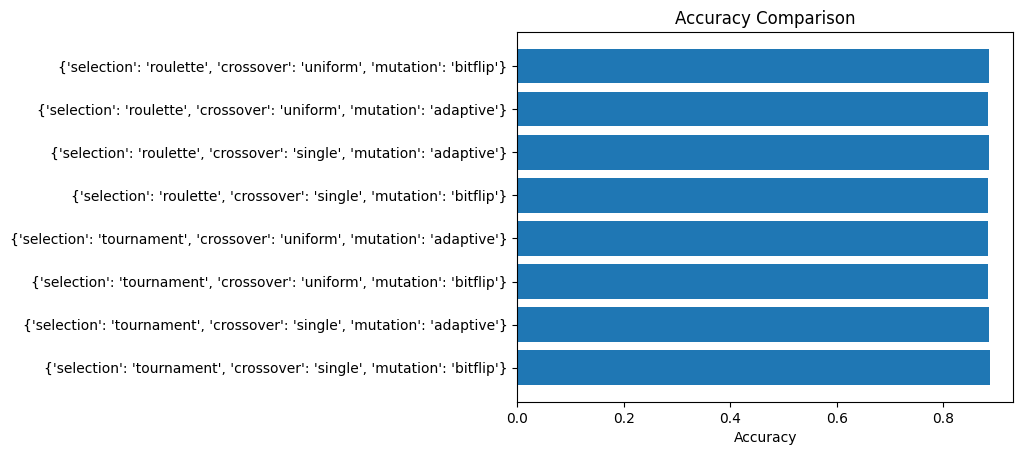

In [33]:
labels = [str(r["config"]) for r in results]
acc_vals = [r["mean_acc"] for r in results]

plt.figure()
plt.barh(labels, acc_vals)
plt.title("Accuracy Comparison")
plt.xlabel("Accuracy")
plt.show()

Runs Progress:   0%|          | 0/30 [58:15<?, ?it/s]


Saved: /kaggle/working/plots/plot_4.png


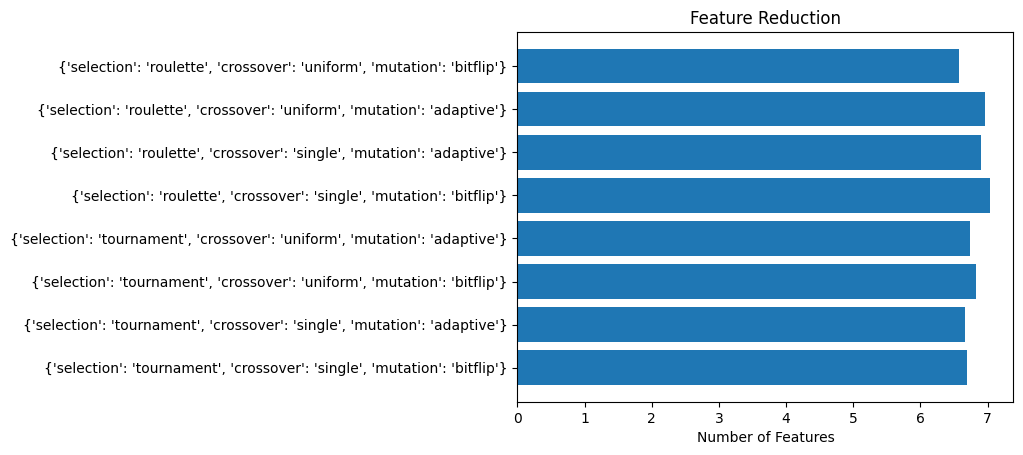

In [34]:
feat_vals = [r["mean_feat"] for r in results]

plt.figure()
plt.barh(labels, feat_vals)
plt.title("Feature Reduction")
plt.xlabel("Number of Features")
plt.show()

Saved: /kaggle/working/plots/plot_5.png


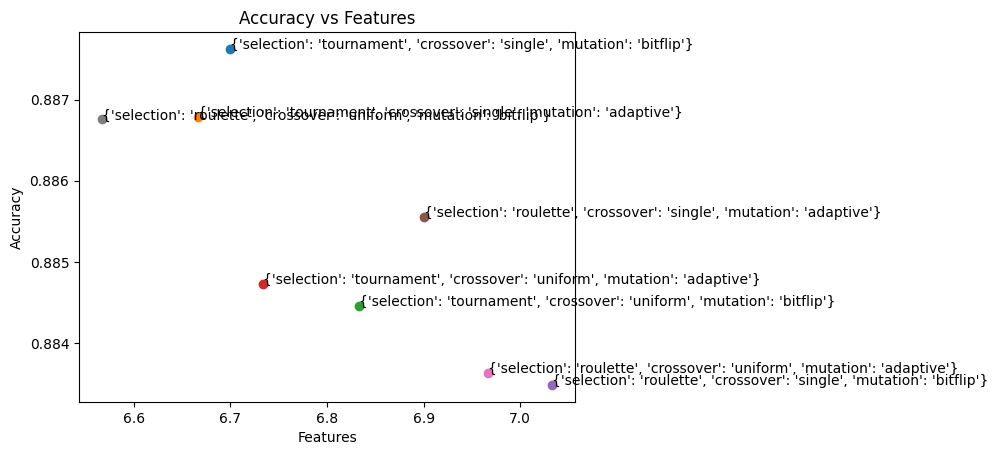

In [35]:
plt.figure()

for r in results:
    plt.scatter(r["mean_feat"], r["mean_acc"])
    plt.text(r["mean_feat"], r["mean_acc"], str(r["config"]))

plt.title("Accuracy vs Features")
plt.xlabel("Features")
plt.ylabel("Accuracy")
plt.show()

Runs Progress:   0%|          | 0/30 [4:00:56<?, ?it/s]


Saved: /kaggle/working/plots/plot_6.png


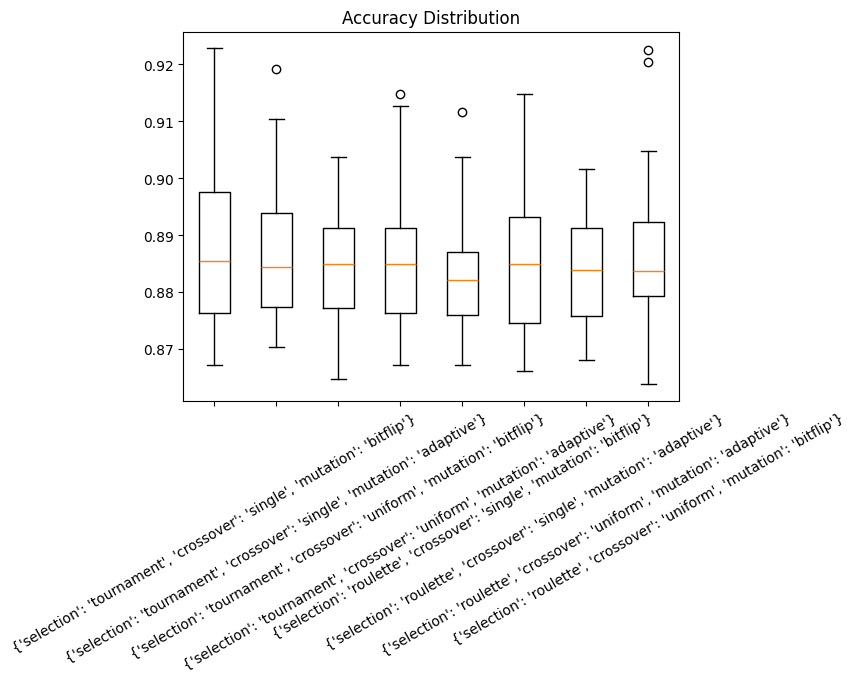

In [36]:
all_acc = [r["all_acc"] for r in results]

plt.figure()
plt.boxplot(all_acc)
plt.title("Accuracy Distribution")
plt.xticks(range(1, len(labels)+1), labels, rotation=30)
plt.show()

Average Fitness Evolution Across Configurations plot

Saved: /kaggle/working/plots/plot_7.png


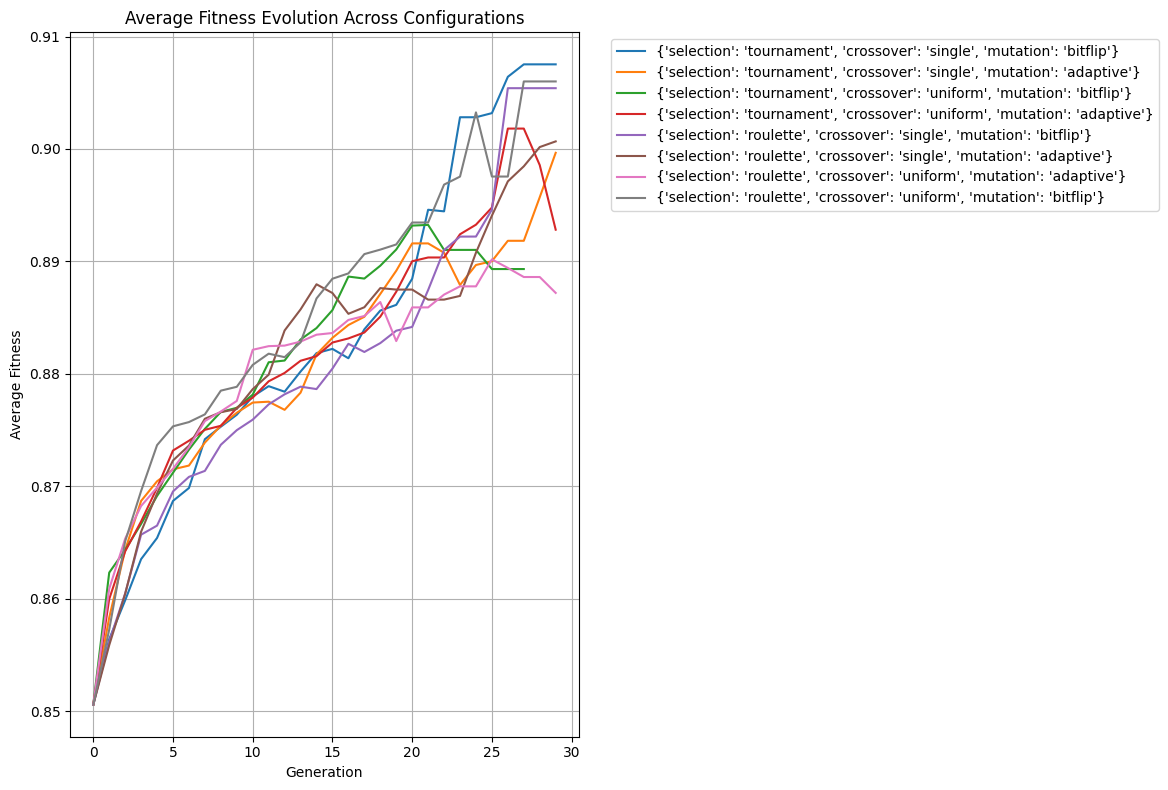

In [37]:
plt.figure(figsize=(12, 8))

for config_str, histories_dict in all_histories.items():
    # 'acc_hist_runs' is a list of lists, where each inner list is the accuracy history for a run.
    # Calculate the mean accuracy history across all runs for this config.

    # Determine the maximum length of histories for this configuration
    max_len = max(len(history) for history in histories_dict['acc_hist_runs'])

    # Pad shorter histories with NaN values to match max_len
    padded_acc_hist_runs = []
    for history in histories_dict['acc_hist_runs']:
        padded_history = np.pad(history, (0, max_len - len(history)), 'constant', constant_values=np.nan)
        padded_acc_hist_runs.append(padded_history)

    # Convert to numpy array and calculate nanmean
    avg_acc_hist = np.nanmean(np.array(padded_acc_hist_runs), axis=0)
    plt.plot(avg_acc_hist, label=config_str)

plt.title("Average Fitness Evolution Across Configurations")
plt.xlabel("Generation")
plt.ylabel("Average Fitness")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.grid()
plt.tight_layout() # Adjust layout to prevent labels from being cut off


save_path = os.path.join(PROJECT_ROOT, "plots", "average_fitness_evolution.png")
os.makedirs(os.path.dirname(save_path), exist_ok=True)

plt.savefig(save_path, bbox_inches='tight')
plt.show()

Average Number of Selected Features Over Generations Across Configurations plot

Saved: /kaggle/working/plots/plot_8.png


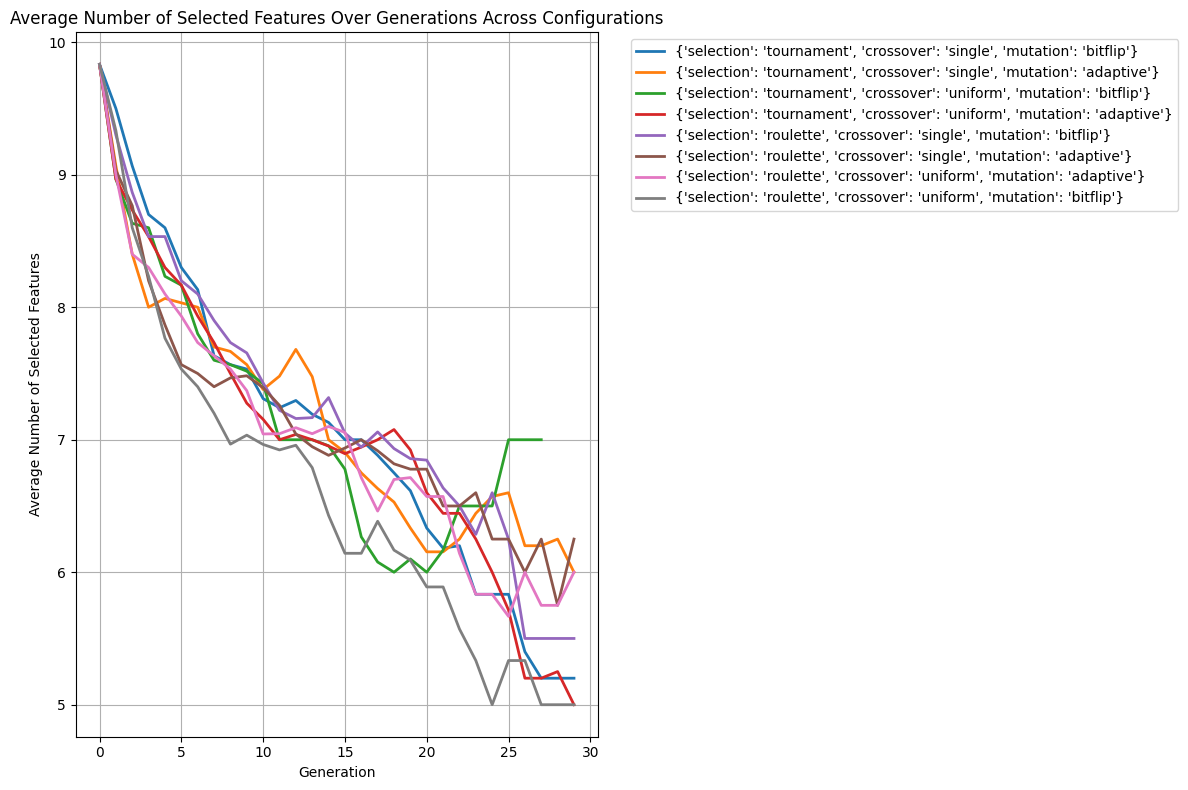

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.figure(figsize=(12, 8))

for config_str, histories_dict in all_histories.items():

    if len(histories_dict['feat_hist_runs']) == 0:
        continue

    max_len = max(len(history) for history in histories_dict['feat_hist_runs'])

    padded_feat_hist_runs = [
        np.pad(np.array(history, dtype=float),
               (0, max_len - len(history)),
               constant_values=np.nan)
        for history in histories_dict['feat_hist_runs']
    ]

    avg_feat_hist = np.nanmean(np.array(padded_feat_hist_runs), axis=0)

    plt.plot(avg_feat_hist, label=config_str, linewidth=2)

plt.title("Average Number of Selected Features Over Generations Across Configurations")
plt.xlabel("Generation")
plt.ylabel("Average Number of Selected Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()

os.makedirs(os.path.join(PROJECT_ROOT, "plots"), exist_ok=True)
plt.savefig(os.path.join(PROJECT_ROOT, "plots", "average_feature_selection_evolution.png"))

plt.show()

Saved: /kaggle/working/plots/plot_14.png


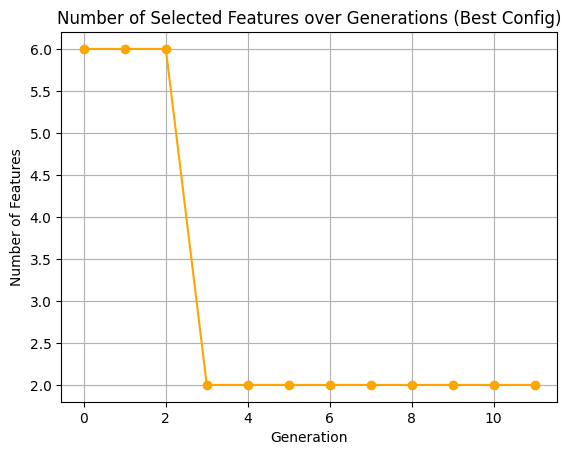

In [60]:
plt.figure()

best_config_str = str(best_config['config'])


feat_hist_runs = all_histories[best_config_str]['feat_hist_runs']
acc_hist_runs  = all_histories[best_config_str]['acc_hist_runs']


final_accuracies = [np.nanmax(run) for run in acc_hist_runs]
best_run_idx = np.argmax(final_accuracies)

#  feature history للـ best run
best_feat_hist = feat_hist_runs[best_run_idx]

plt.plot(best_feat_hist, marker='o', color='orange')

plt.title("Number of Selected Features over Generations (Best Config)")
plt.xlabel("Generation")
plt.ylabel("Number of Features")
plt.grid()

plt.show()

## Factor **analysis** & **effect**

# Selection Effect on Accuracy

In [40]:
tournament_acc = []
roulette_acc   = []

for r in results:
    if r["config"]["selection"] == "tournament":
        tournament_acc.extend(r["all_acc"])   # ← extend with all 30 runs
    else:
        roulette_acc.extend(r["all_acc"])     # ← not append(mean_acc)

print("Tournament Avg:", np.mean(tournament_acc))
print("Roulette Avg:",   np.mean(roulette_acc))

Tournament Avg: 0.8858978060493397
Roulette Avg: 0.884856023198172


Saved: /kaggle/working/plots/plot_9.png


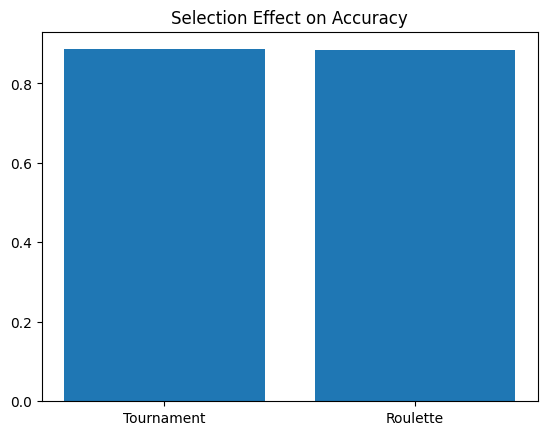

In [41]:
plt.figure()
plt.bar(["Tournament", "Roulette"],
        [np.mean(tournament_acc), np.mean(roulette_acc)])
plt.title("Selection Effect on Accuracy")
plt.show()

In [42]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(tournament_acc, roulette_acc)

print("\n--- Statistical Significance Test (Tournament vs. Roulette) ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant difference between the two selection methods (p < 0.05).")
else:
    print("Conclusion: There is no statistically significant difference between the two selection methods (p >= 0.05).")


--- Statistical Significance Test (Tournament vs. Roulette) ---
T-statistic: 0.6769
P-value: 0.4991
Conclusion: There is no statistically significant difference between the two selection methods (p >= 0.05).


# Crossover Effect on Accuracy

In [43]:
single_acc = []
uniform_acc = []

for r in results:
    if r["config"]["crossover"] == "single":
        single_acc.append(r["mean_acc"])
    else:
        uniform_acc.append(r["mean_acc"])

print("\nCrossover Analysis:")
print("Single Avg:", np.mean(single_acc))
print("Uniform Avg:", np.mean(uniform_acc))


Crossover Analysis:
Single Avg: 0.8858599056969132
Uniform Avg: 0.8848939235505984


In [44]:
t_stat_crossover, p_value_crossover = stats.ttest_ind(single_acc, uniform_acc)

print("\n--- Statistical Significance Test (Single vs. Uniform Crossover) ---")
print(f"T-statistic: {t_stat_crossover:.4f}")
print(f"P-value: {p_value_crossover:.4f}")

if p_value_crossover < 0.05:
    print("Conclusion: There is a statistically significant difference between the two crossover methods (p < 0.05).")
else:
    print("Conclusion: There is no statistically significant difference between the two crossover methods (p >= 0.05).")


--- Statistical Significance Test (Single vs. Uniform Crossover) ---
T-statistic: 0.8646
P-value: 0.4205
Conclusion: There is no statistically significant difference between the two crossover methods (p >= 0.05).


Saved: /kaggle/working/plots/plot_10.png


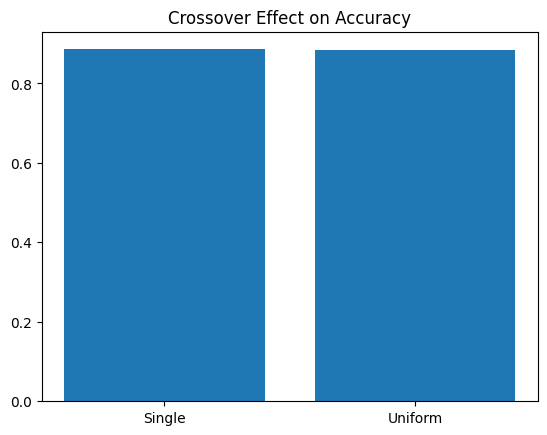

In [45]:
plt.figure()
plt.bar(["Single", "Uniform"],
        [np.mean(single_acc), np.mean(uniform_acc)])
plt.title("Crossover Effect on Accuracy")
plt.show()

# Mutation Effect on Accuracy

In [46]:
bitflip_acc = []
adaptive_acc = []

for r in results:
    if r["config"]["mutation"] == "bitflip":
        bitflip_acc.append(r["mean_acc"])
    else:
        adaptive_acc.append(r["mean_acc"])

print("\nMutation Analysis:")
print("Bitflip Avg:", np.mean(bitflip_acc))
print("Adaptive Avg:", np.mean(adaptive_acc))


Mutation Analysis:
Bitflip Avg: 0.8855794653576547
Adaptive Avg: 0.885174363889857


In [47]:
t_stat_mutation, p_value_mutation = stats.ttest_ind(bitflip_acc, adaptive_acc)

print("\n--- Statistical Significance Test (Bitflip vs. Adaptive Mutation) ---")
print(f"T-statistic: {t_stat_mutation:.4f}")
print(f"P-value: {p_value_mutation:.4f}")

if p_value_mutation < 0.05:
    print("Conclusion: There is a statistically significant difference between the two mutation methods (p < 0.05).")
else:
    print("Conclusion: There is no statistically significant difference between the two mutation methods (p >= 0.05).")


--- Statistical Significance Test (Bitflip vs. Adaptive Mutation) ---
T-statistic: 0.3453
P-value: 0.7416
Conclusion: There is no statistically significant difference between the two mutation methods (p >= 0.05).


Saved: /kaggle/working/plots/plot_11.png


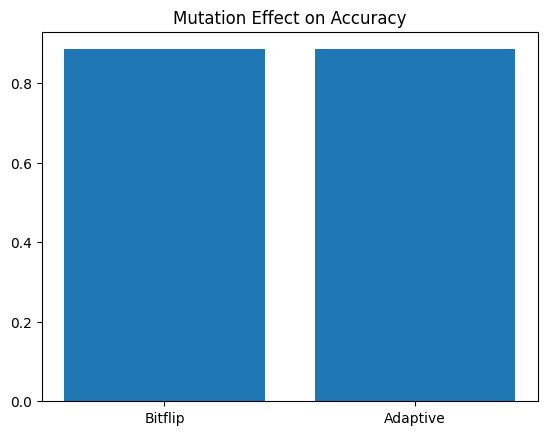

In [48]:
plt.figure()
plt.bar(["Bitflip", "Adaptive"],
        [np.mean(bitflip_acc), np.mean(adaptive_acc)])
plt.title("Mutation Effect on Accuracy")
plt.show()

In [49]:
from scipy.stats import pearsonr

# Extract mean features and mean accuracy for all configurations
mean_features = [r['mean_feat'] for r in results]
mean_accuracies = [r['mean_acc'] for r in results]

# Calculate Pearson correlation coefficient and p-value
correlation, p_value = pearsonr(mean_features, mean_accuracies)

print(f"Correlation between Mean Features and Mean Accuracy: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant correlation between the number of features and accuracy (p < 0.05).")
else:
    print("Conclusion: There is no statistically significant correlation between the number of features and accuracy (p >= 0.05).")

Correlation between Mean Features and Mean Accuracy: -0.8247
P-value: 0.0118
Conclusion: There is a statistically significant correlation between the number of features and accuracy (p < 0.05).


In [50]:
# Identify the best configuration key
best_config_key  = str(best_config['config'])
best_solutions   = all_histories[best_config_key]['best_solutions']
acc_hist_runs    = all_histories[best_config_key]['acc_hist_runs']

# Find the run with the highest peak fitness across all 30 runs
run_peak_acc     = [max(hist) for hist in acc_hist_runs]
best_run_idx     = int(np.argmax(run_peak_acc))

# Use that run's best chromosome — not arbitrarily run[0]
best_solution_chromosome = best_solutions[best_run_idx]
selected_feature_indices = np.where(best_solution_chromosome == 1)[0]

print(f"Best configuration : {best_config_key}")
print(f"Best run index     : {best_run_idx} (peak fitness: {run_peak_acc[best_run_idx]:.4f})")
print(f"Features selected  : {len(selected_feature_indices)} / {n_features}")
print(f"Selected indices   : {selected_feature_indices.tolist()}")


Best configuration : {'selection': 'tournament', 'crossover': 'single', 'mutation': 'bitflip'}
Best run index     : 29 (peak fitness: 0.9228)
Features selected  : 2 / 30
Selected indices   : [23, 28]


# Final Model Training & Evaluation

Train the final classifier on the feature subset selected by the GA,
then evaluate with a full set of metrics on the held-out test set.
A **stronger Random Forest** (300 trees, no depth cap) is used here — the
GA used only 50 trees to keep fitness evaluation fast.


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Use the chromosome identified in the cell above
selected_indices  = selected_feature_indices
n_sel             = len(selected_indices)

X_train_selected = X_train[:, selected_indices]
X_test_selected  = X_test[:, selected_indices]

print(f"Original shape  : {X_train.shape[1]} features")
print(f"Selected shape  : {n_sel} features ({100*(1-n_sel/n_features):.1f}% reduction)")
print(f"Indices         : {selected_indices.tolist()}")


Original shape  : 30 features
Selected shape  : 2 features (93.3% reduction)
Indices         : [23, 28]


In [52]:
# Stronger classifier for the final evaluation.
# During the GA we used n_estimators=50 and max_depth=8 purely for speed.
# Here we lift those restrictions so the comparison is fair.
final_classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,      # no artificial depth cap
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)
final_classifier.fit(X_train_selected, y_train)
print(f"✅ Final classifier trained on {n_sel} selected features.")


✅ Final classifier trained on 2 selected features.


In [53]:
y_pred      = final_classifier.predict(X_test_selected)
y_pred_prob = final_classifier.predict_proba(X_test_selected)[:, 1]

print(f"\n{'='*50}")
print(f" GA-selected model  ({n_sel} / {n_features} features)")
print(f"{'='*50}")
print(f" Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f" Precision : {precision_score(y_test, y_pred):.4f}")
print(f" Recall    : {recall_score(y_test, y_pred):.4f}"
      " # sensitivity — malignant detection rate")
print(f" F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f" AUC-ROC   : {roc_auc_score(y_test, y_pred_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

# Store for comparison
ga_metrics = {
    'accuracy' : accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall'   : recall_score(y_test, y_pred),
    'f1'       : f1_score(y_test, y_pred),
    'auc'      : roc_auc_score(y_test, y_pred_prob),
}



 GA-selected model  (2 / 30 features)
 Accuracy  : 0.8947
 Precision : 0.8947
 Recall    : 0.8095 # sensitivity — malignant detection rate
 F1 Score  : 0.8500
 AUC-ROC   : 0.9719

              precision    recall  f1-score   support

      Benign       0.89      0.94      0.92        72
   Malignant       0.89      0.81      0.85        42

    accuracy                           0.89       114
   macro avg       0.89      0.88      0.88       114
weighted avg       0.89      0.89      0.89       114



# Baseline: All 30 Features

Same strong classifier trained on all 30 features — no feature selection.
This is the baseline the GA result is compared against.


In [54]:
full_feature_classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)
full_feature_classifier.fit(X_train, y_train)
print("✅ Baseline classifier trained on all 30 features.")


✅ Baseline classifier trained on all 30 features.


# Model Comparison


In [55]:
y_pred_full      = full_feature_classifier.predict(X_test)
y_pred_full_prob = full_feature_classifier.predict_proba(X_test)[:, 1]

print(f"\n{'='*50}")
print(f" Baseline model  (all {n_features} features)")
print(f"{'='*50}")
print(f" Accuracy  : {accuracy_score(y_test, y_pred_full):.4f}")
print(f" Precision : {precision_score(y_test, y_pred_full):.4f}")
print(f" Recall    : {recall_score(y_test, y_pred_full):.4f}")
print(f" F1 Score  : {f1_score(y_test, y_pred_full):.4f}")
print(f" AUC-ROC   : {roc_auc_score(y_test, y_pred_full_prob):.4f}")
print()
print(classification_report(y_test, y_pred_full, target_names=['Benign', 'Malignant']))

base_metrics = {
    'accuracy' : accuracy_score(y_test, y_pred_full),
    'precision': precision_score(y_test, y_pred_full),
    'recall'   : recall_score(y_test, y_pred_full),
    'f1'       : f1_score(y_test, y_pred_full),
    'auc'      : roc_auc_score(y_test, y_pred_full_prob),
}

# Summary comparison table
print(f"\n{'─'*58}")
print(f"{'Metric':<12} {'GA (' + str(n_sel) + ' features)':>20} {'Baseline (30)':>20}")
print(f"{'─'*58}")
for metric in ['accuracy','precision','recall','f1','auc']:
    ga_val   = ga_metrics[metric]
    base_val = base_metrics[metric]
    arrow    = '▲' if ga_val >= base_val else '▼'
    print(f"{metric.capitalize():<12} {ga_val:>20.4f} {base_val:>20.4f}  {arrow}")
print(f"{'─'*58}")
print(f"Feature reduction : {100*(1 - n_sel/n_features):.1f}%")



 Baseline model  (all 30 features)
 Accuracy  : 0.9737
 Precision : 1.0000
 Recall    : 0.9286
 F1 Score  : 0.9630
 AUC-ROC   : 0.9944

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


──────────────────────────────────────────────────────────
Metric            GA (2 features)        Baseline (30)
──────────────────────────────────────────────────────────
Accuracy                   0.8947               0.9737  ▼
Precision                  0.8947               1.0000  ▼
Recall                     0.8095               0.9286  ▼
F1                         0.8500               0.9630  ▼
Auc                        0.9719               0.9944  ▼
──────────────────────────────────────────────────────────
Feature reduc

Saved: /kaggle/working/plots/plot_12.png


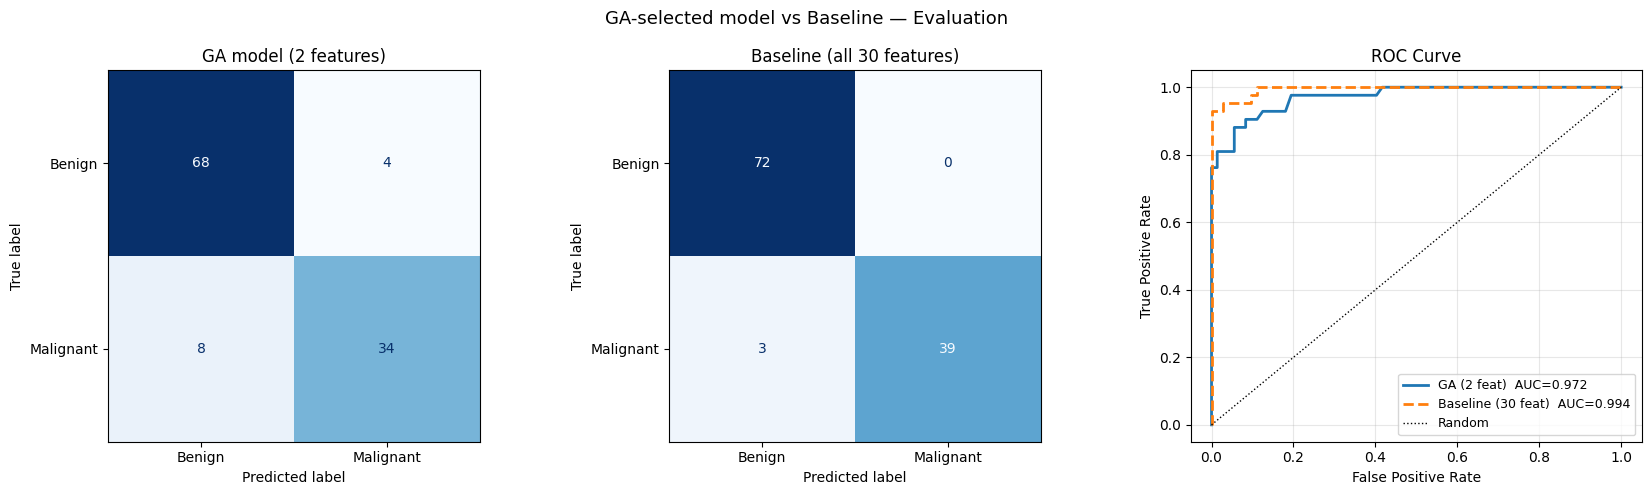

Saved: /kaggle/working/plots/plot_13.png


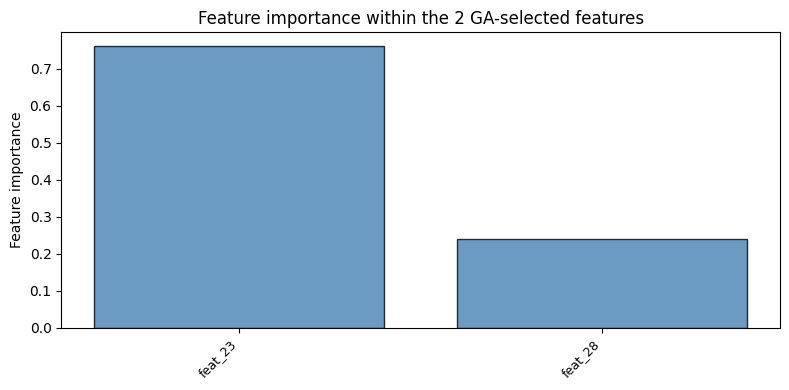

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Confusion matrices ────────────────────────────────────────────────────
for ax, y_p, title in [
    (axes[0], y_pred,      f'GA model ({n_sel} features)'),
    (axes[1], y_pred_full, f'Baseline (all {n_features} features)'),
]:
    cm = confusion_matrix(y_test, y_p)
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(
        ax=ax, cmap=plt.cm.Blues, colorbar=False
    )
    ax.set_title(title)

# ── ROC curves (both models on same axes) ─────────────────────────────────
for y_p, lbl, ls in [
    (y_pred_prob,      f'GA ({n_sel} feat)',    '-'),
    (y_pred_full_prob, f'Baseline ({n_features} feat)', '--'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_p)
    auc_val     = roc_auc_score(y_test, y_p)
    axes[2].plot(fpr, tpr, ls=ls, lw=2, label=f'{lbl}  AUC={auc_val:.3f}')

axes[2].plot([0,1],[0,1],'k:',lw=1,label='Random')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('GA-selected model vs Baseline — Evaluation', fontsize=13)
plt.tight_layout()
plt.show()

# ── Feature importance of the GA-selected features ────────────────────────
importances = final_classifier.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(n_sel), importances[sorted_idx], color='steelblue', edgecolor='black', alpha=0.8)
plt.xticks(range(n_sel),
           [f'feat_{selected_indices[i]}' for i in sorted_idx],
           rotation=45, ha='right', fontsize=9)
plt.ylabel('Feature importance')
plt.title(f'Feature importance within the {n_sel} GA-selected features')
plt.tight_layout()
plt.show()


In [ ]:
import pickle

with open("/kaggle/working/final_results.pkl", "wb") as f:
    pickle.dump({ "results": results, "all_histories": all_histories}, f)

print("✅ Saved successfully")

✅ Saved successfully
